<a href="https://colab.research.google.com/github/Shrut2112/Tampered_image_classification/blob/main/DataGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fiftyone --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.5/934.5 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.1 MB/s eta 0:00

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
import fiftyone as fo
import fiftyone.zoo as foz
from pathlib import Path
from tqdm import tqdm
import random
import json
from PIL import Image
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


## Loading the Dataset for the first time

MS-COCO is the industry standard for high-quality, real-world imagery with  pixel-level instance segmentation. It serves as the perfect baseline because its diverse scenes provide a wide variety of natural lighting and camera noise. This variety ensures the model learns to identify forensic inconsistencies rather than just memorizing a specific type of background.

In [ ]:
drive_export_dir = "/content/drive/MyDrive/Big_Vision_Assignment/working/coco_clean"

print("Downloading/Loading COCO from Zoo...")
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    label_types=["segmentations"],
    shuffle=True,
    seed=42,
    max_samples=4000,
)

print(f"Exporting to {drive_export_dir}...")
dataset.export(
    export_dir=drive_export_dir,
    dataset_type=fo.types.COCODetectionDataset,
    label_field="ground_truth",
    abs_paths=True
)

print("Setup Complete! You can now restart your runtime and use Part 2.")

Downloading/Loading COCO from Zoo...


INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/coco-2017/validation' if necessary


INFO:fiftyone.utils.coco:Downloading annotations to '/root/fiftyone/coco-2017/tmp-download/annotations_trainval2017.zip'


 100% |██████|    1.9Gb/1.9Gb [2.5s elapsed, 0s remaining, 861.7Mb/s]       


INFO:eta.core.utils: 100% |██████|    1.9Gb/1.9Gb [2.5s elapsed, 0s remaining, 861.7Mb/s]       


...

Dataset 'coco-2017-validation-4000' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-validation-4000' created


Exporting to /content/drive/MyDrive/Big_Vision_Assignment/working/coco_clean...
 100% |███████████████| 4000/4000 [7.3m elapsed, 0s remaining, 6.9 samples/s]       


INFO:eta.core.utils: 100% |███████████████| 4000/4000 [7.3m elapsed, 0s remaining, 6.9 samples/s]       


Setup Complete! You can now restart your runtime and use Part 2.


In [ ]:
# Building the csv file for further tampering process this will be used as the main file
print("Computing image metadata...")
dataset.compute_metadata()

dataset_metadata = []

for sample in tqdm(dataset, desc="Building Essential Manifest"):
    dataset_metadata.append({
        "coco_id": sample.id,
        "full_path": sample.filepath,
        "width": sample.metadata.width,
        "height": sample.metadata.height,
        "label": 0,
        "tamper_type": "real"
    })

df = pd.DataFrame(dataset_metadata)
MANIFEST_PATH = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset_manifest.csv"
df.to_csv(MANIFEST_PATH, index=False)

print(f"Minimalist Manifest Saved: {len(df)} rows")


Computing image metadata...


Building Essential Manifest: 100%|██████████| 4000/4000 [00:23<00:00, 166.81it/s]


Minimalist Manifest Saved: 4000 rows


In [ ]:
ACTUAL_DRIVE_FOLDER = "/content/drive/MyDrive/Big_Vision_Assignment/working/coco_clean/data"

def fix_manifest_paths(df, folder_path):
    def repair(original_path):
        filename = os.path.basename(original_path)
        return os.path.join(folder_path, filename)

    df['full_path'] = df['full_path'].apply(repair)
    return df

df_new = fix_manifest_paths(df, ACTUAL_DRIVE_FOLDER)
df_new.to_csv("/content/drive/MyDrive/Big_Vision_Assignment/working/dataset_manifest.csv", index=False)
print("Manifest paths synced to Google Drive!")

Manifest paths synced to Google Drive!


In [ ]:
df_new.shape

(4000, 6)

**Reloading Function** - instead of downloading dataset again and again directly loading from the drive

In [ ]:
dataset = fo.Dataset.from_dir(
    dataset_dir="/content/drive/MyDrive/Big_Vision_Assignment/working/coco_clean",
    dataset_type=fo.types.COCODetectionDataset,
    label_field="ground_truth",
    name="coco_session_v2"
)

df = pd.read_csv("/content/drive/MyDrive/Big_Vision_Assignment/working/dataset_manifest.csv")
print(f"Reloaded {len(dataset)} samples and {len(df)} manifest rows.")

 100% |███████████████| 4000/4000 [2.1m elapsed, 0s remaining, 41.5 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 4000/4000 [2.1m elapsed, 0s remaining, 41.5 samples/s]      


Reloaded 4000 samples and 4000 manifest rows.


In [ ]:
print(dataset.first().field_names)

('id', 'filepath', 'tags', 'metadata', 'created_at', 'last_modified_at', 'ground_truth_detections', 'ground_truth_segmentations')


The pipeline goes beyond the three common spatial techniques (Copy-Move, Inpainting, Splicing) to include Frequency Domain (DCT) and Local Colour Manipulation because real-world forgeries are not limited to structural edits. Professional photo manipulation tools operate at the codec and colour statistics level - leaving no visible trace but creating measurable statistical inconsistencies in compression coefficients and channel distributions. Including these techniques forces the model to learn forensic signals beyond object boundaries and spatial duplication - training it to detect invisible artifacts like double-compression fingerprints and HSV channel breaks that purely spatial techniques would never expose it to.

## Working on the loaded Dataset

Each COCO category is assigned a base score reflecting how suitable it is for tampering - solid, movable objects like animals and vehicles score highest (50), while context-bound objects like traffic lights and clocks are excluded entirely (0) as they would look semantically implausible when moved or duplicated.

In [ ]:
OBJECT_TIERS = {
    "person": 25, "sheep": 50, "cow": 50, "elephant": 50, "zebra": 50, "giraffe": 50,
    "car": 50, "bottle": 45, "cup": 45, "chair": 45, "banana": 45, "apple": 45,
    "orange": 45, "broccoli": 45, "carrot": 45, "bowl": 45, "bird": 40,

    "dog": 35, "cat": 35, "horse": 35, "motorcycle": 35, "bus": 35, "truck": 35,
    "bench": 35, "backpack": 35, "handbag": 35, "suitcase": 35, "frisbee": 35,
    "sports ball": 35, "baseball bat": 30, "baseball glove": 30, "skateboard": 30,
    "surfboard": 30, "wine glass": 30, "knife": 30, "spoon": 30,
    "fork": 30, "potted plant": 30, "dining table": 15,

    "bicycle": 20, "umbrella": 20, "tie": 0, "skis": 20, "snowboard": 20,
    "kite": 15, "cake": 20, "pizza": 20, "donut": 20, "sandwich": 20,
    "laptop": 25, "mouse": 25, "keyboard": 25, "cell phone": 25,
    "microwave": 20, "oven": 20, "toaster": 20, "sink": 20, "refrigerator": 20,
    "tennis racket": 20,

    "traffic light": 0, "stop sign": 0, "fire hydrant": 0, "parking meter": 0,
    "clock": 0, "toilet": 0, "tv": 0, "bed": 0, "hair drier": 0, "toothbrush": 0,
    "teddy bear": 10, "book": 10
}

## Finding the best Object

In [ ]:
#The function scores every detected object in the image and returns the best candidate for tampering
def select_best_object(sample, img_w, img_h, min_area=0.005, max_area=0.50):
    detections = sample.ground_truth_segmentations.detections
    if not detections:
        print("No Detection")
        return None

    candidates = []

    for det in detections:

        if det.mask is None:
            print("No mask")
            continue                          # no mask = skip

        x, y, w, h = det.bounding_box
        area = w * h

        # scores on area
        if area < min_area:                   # too tiny
            continue
        if area > max_area:                   # dominates image
            continue

        margin = 0.01
        if x < margin or y < margin:
            continue
        if (x + w) > (1 - margin):
            continue
        if (y + h) > (1 - margin):
            continue

        label_score = OBJECT_TIERS.get(det.label, 15)  # unknown = 15
        if label_score == 0:
            continue

        score = label_score

        if area < 0.005:
            continue
        elif 0.005 <= area < 0.02:
            score += 20
        elif 0.02 <= area <= 0.12:
            score += 40
        elif 0.12 < area <= 0.5:
            score += 15
        elif area > 0.5:
            score -= 20

        mask_pixels  = det.mask.sum()
        bbox_pixels  = det.mask.shape[0] * det.mask.shape[1]
        solidity     = mask_pixels / (bbox_pixels + 1e-5)

        # score on solidity
        if solidity > 0.55:
            score += 25  # more solid
        elif solidity > 0.35:
            score += 10 # descent
        else:
            score += 0

        #score on aspect ratio
        aspect = w / (h + 1e-5)
        if 0.4 <= aspect <= 2.5:
            score += 10
        else:
            score -= 10

        candidates.append((det, score))

    if not candidates:
        print("No candidates")
        return None

    candidates.sort(key=lambda c: c[1], reverse=True)

    top_k   = min(3, len(candidates))
    chosen  = random.choice(candidates[:top_k])

    return chosen[0]

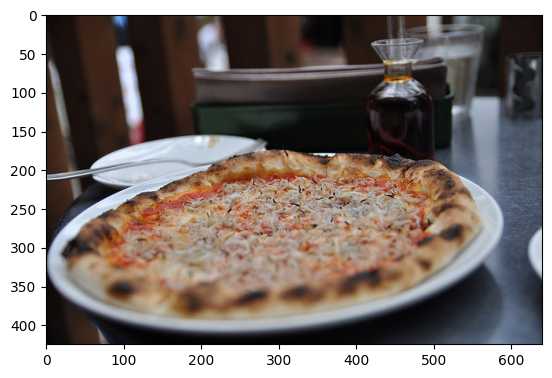

<Detection: {
    'id': '69b398772afdf8c430f36140',
    'attributes': {},
    'tags': [],
    'label': 'cup',
    'bounding_box': [
        0.723640625,
        0.029458823529411763,
        0.16278125000000002,
        0.2871764705882353,
    ],
    'mask': array([[False, False, False, ..., False, False, False],
           [False, False, False, ...,  True,  True, False],
           [False, False, False, ...,  True, False, False],
           ...,
           [False, False, False, ..., False, False, False],
           [False, False, False, ..., False, False, False],
           [False, False, False, ..., False, False, False]]),
    'mask_path': None,
    'confidence': None,
    'index': None,
    'iscrowd': 0,
    'supercategory': 'kitchen',
}>
✅ Selected object: cup


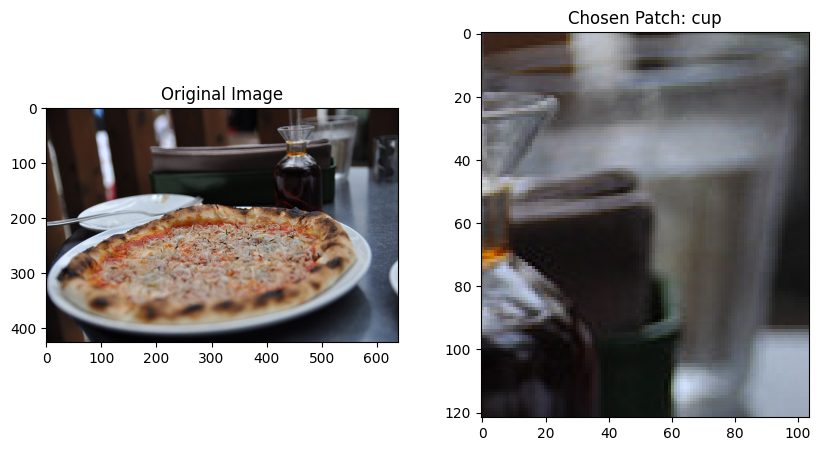

In [ ]:
row = df.iloc[243]
sample = dataset[row["full_path"]]

img_bgr = cv2.imread(row["full_path"])
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape
plt.imshow(img_rgb)
plt.show()

chosen = select_best_object(sample, w, h)
print(chosen)
if chosen:
    print(f"✅ Selected object: {chosen.label}")

    lx, ty, bw, bh = chosen.bounding_box
    x1, y1 = int(lx * w), int(ty * h)
    mw, mh = int(bw * w), int(bh * h)

    obj_patch = img_rgb[y1:y1+mh, x1:x1+mw]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(obj_patch)
    plt.title(f"Chosen Patch: {chosen.label}")
    plt.show()
else:
    print("No suitable object found (High-quality filters rejected all candidates)")

## Finding suitable location for the object placement

In [ ]:
# finds histogram to match texture and colour pattern
def get_source_histogram(img, bbox, border=20):
    x1, y1, x2, y2 = bbox
    h, w = img.shape[:2]

    x1b = max(0, x1 - border)
    y1b = max(0, y1 - border)
    x2b = min(w, x2 + border)
    y2b = min(h, y2 + border)

    if x1b >= x2b or y1b >= y2b:
        return None

    patch = img[y1b:y2b, x1b:x2b]

    if patch is None or patch.size == 0:
        return None
    if patch.shape[0] < 2 or patch.shape[1] < 2:
        return None

    try:
        # converts into hsv format as Histogram calculation in hsv is
        hsv  = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0,1], None, [50,60], [0,180,0,256])
        cv2.normalize(hist, hist)
        return hist
    except Exception:
        return None


In [ ]:
# generates random 100 candidates
def generate_candidates(img_w, img_h, obj_w, obj_h, n=100):

    candidates = []
    margin = 20
    x_max  = img_w - obj_w - margin
    y_max  = img_h - obj_h - margin

    if x_max <= margin or y_max <= margin:
        return []

    for _ in range(n):

        x = random.randint(0, img_w - obj_w)
        y = random.randint(0, img_h - obj_h)

        candidates.append((x, y, x+obj_w, y+obj_h))

    return candidates

In [ ]:
def iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])

    return inter/(areaA+areaB-inter+1e-6)

In [ ]:
# matches similarity of the object patch with the location patch
def histogram_similarity(img, candidate_box, source_hist):
    if source_hist is None:
        return -1

    x1, y1, x2, y2 = candidate_box
    h_img, w_img   = img.shape[:2]

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w_img, x2)
    y2 = min(h_img, y2)

    if x1 >= x2 or y1 >= y2:
        return -1

    patch = img[y1:y2, x1:x2]

    if patch is None or patch.size == 0:
        return -1
    if patch.shape[0] < 2 or patch.shape[1] < 2:
        return -1

    try:
        hsv  = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0,1], None, [50,60], [0,180,0,256])
        cv2.normalize(hist, hist)

        if hist.shape != source_hist.shape:
            return -1

        return cv2.compareHist(source_hist, hist, cv2.HISTCMP_CORREL)
    except Exception:
        return -1

In [ ]:
# finds best location by comparing the colour pattern, avoiding ovrlap between the objects, and mainting y-axis distance
def find_best_location(img, source_bbox, obj_w, obj_h, existing_boxes):
    h, w = img.shape[:2]

    sx1, sy1, sx2, sy2 = source_bbox
    sx1c = max(0, min(sx1, w-1))
    sy1c = max(0, min(sy1, h-1))
    sx2c = max(0, min(sx2, w))
    sy2c = max(0, min(sy2, h))

    if sx1c >= sx2c or sy1c >= sy2c:
        return None

    clamped_bbox = (sx1c, sy1c, sx2c, sy2c)

     # compute HSV histogram of the source region to use as colour reference
    source_hist = get_source_histogram(img, clamped_bbox)
    if source_hist is None:
        return None

    candidates = generate_candidates(w, h, obj_w, obj_h)
    if not candidates:
        return None

    src_cx = (sx1 + sx2) / 2
    src_cy = (sy1 + sy2) / 2

    best_score = -1
    best_box   = None

    for box in candidates:
        x1, y1, x2, y2 = box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        dist = np.sqrt((src_cx-cx)**2 + (src_cy-cy)**2)
        # minimum distance check - target must be at least 1.2x object width away
        # from source, prevents the copy from visually overlapping the original
        if dist < (obj_w * 1.2):
            continue

        y_shift = (cy - src_cy) / h
        # vertical displacement constraint - target can be at most 20% lower or 5% higher
        # than the source in the frame, mimics real-world perspective where objects
        # at similar depths occupy similar vertical positions in the scene
        if y_shift < -0.05 or y_shift > 0.20:
            continue

        # IoU check - reject candidate if it overlaps any existing COCO object
        if any(iou(box, ex) > 0.05 for ex in existing_boxes):
            continue

        # histogram similarity - compare HSV colour distribution of candidate region
        score = histogram_similarity(img, box, source_hist)
        if score < 0.35:
            continue

        if score > best_score:
            best_score = score
            best_box   = box

    return best_box

In [ ]:
#Testing Only
# num_results = 10
# cols = 2
# rows = (num_results + cols - 1) // cols

# plt.figure(figsize=(10, 5 * rows))

# count = 0
# for _ in range(num_results):

#     row = df.iloc[random.randint(0, len(df) - 1)]
#     sample = dataset[row["full_path"]]

#     img_bgr = cv2.imread(row["full_path"])
#     if img_bgr is None: continue
#     img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#     img_h, img_w, _ = img_rgb.shape

#     if not sample.ground_truth_segmentations:
#       continue
#     existing_boxes = []
#     for det in sample.ground_truth_segmentations.detections:
#         det_x, det_y, det_w, det_h = det.bounding_box
#         x1, y1 = int(det_x * img_w), int(det_y * img_h)
#         x2, y2 = int((det_x + det_w) * img_w), int((det_y + det_h) * img_h)
#         existing_boxes.append((x1, y1, x2, y2))

#     chosen = select_best_object(sample, img_w, img_h)
#     if chosen is None: continue

#     lx, ty, bw, bh = chosen.bounding_box
#     cx1, cy1 = int(lx * img_w), int(ty * img_h)
#     cx2, cy2 = int((lx + bw) * img_w), int((ty + bh) * img_h)
#     source_bbox = (cx1, cy1, cx2, cy2)

#     box = find_best_location(img_rgb, source_bbox, (cx2-cx1), (cy2-cy1), existing_boxes)

#     count += 1
#     ax = plt.subplot(rows, cols, count)
#     output_img = img_rgb.copy()

#     if box is not None:

#         cv2.rectangle(output_img, (source_bbox[0], source_bbox[1]), (source_bbox[2], source_bbox[3]), (255, 0, 0), 4)

#         cv2.rectangle(output_img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 4)
#         ax.set_title(f"Match Found", color='green')
#     else:
#         ax.set_title(f"No Match", color='red')

#     ax.imshow(output_img)
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

Pasting the patch

A direct copy-paste without any transformation would create an exact pixel-level duplicate - trivially detectable by even a simple block-matching algorithm. By applying a random rotation (±15°) and perspective-aware scaling, the copied patch is no longer an identical clone of the source, making it harder to detect via direct pixel comparison

In [ ]:
def apply_geometric_transform(src_patch, mask, scale_factor=1.0):

    h, w = src_patch.shape[:2]
    cx, cy = w / 2, h / 2

    angle = random.uniform(-15, 15)

    M = cv2.getRotationMatrix2D((cx, cy), angle, scale_factor)

    src_transformed = cv2.warpAffine(
        src_patch, M, (w, h),
        flags=cv2.INTER_LANCZOS4,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )
    mask_transformed = cv2.warpAffine(
        mask, M, (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return src_transformed, mask_transformed

In [ ]:
def compute_scale_factor(source_bbox, target_box, img_h):

    src_cy = (source_bbox[1] + source_bbox[3]) / 2
    tgt_cy = (target_box[1]  + target_box[3])  / 2

    y_diff = (tgt_cy - src_cy) / img_h

    if y_diff > 0.05:
        scale = 1.0 + (y_diff * 0.5)
        scale = min(scale, 1.5)
    elif y_diff < -0.05:
        scale = 1.0 + (y_diff * 0.5)
        scale = max(scale, 0.3)
    else:
        scale = 1.0

    return round(scale, 3)

In [ ]:
def paste_object(img_rgb, chosen_obj, source_bbox, target_box):

    h_img, w_img = img_rgb.shape[:2]

    x1, y1, x2, y2 = source_bbox
    src_patch = img_rgb[y1:y2, x1:x2].copy()
    obj_h, obj_w = src_patch.shape[:2]

    # convert COCO mask to binary uint8 and resize to match patch dimensions
    mask = (chosen_obj.mask * 255).astype(np.uint8)
    mask = cv2.resize(mask, (obj_w, obj_h), interpolation=cv2.INTER_NEAREST)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    scale_factor = compute_scale_factor(source_bbox, target_box, h_img)

    src_patch, mask = apply_geometric_transform(src_patch, mask, scale_factor)
    print(f"  scale={scale_factor} | angle=random±15°")

    # erode mask by 2 iterations to pull edges inward - prevents halo artifacts
    # at object boundary where background pixels bleed into the paste
    kernel        = np.ones((3, 3), np.uint8)
    mask_eroded   = cv2.erode(mask, kernel, iterations=2)

    # gaussian blur on eroded mask creates a smooth feathered alpha channel
    # mimics soft brush falloff of real editing tools - no hard boundary visible
    mask_feathered = cv2.GaussianBlur(mask_eroded, (7, 7), 0)
    alpha  = mask_feathered.astype(np.float32) / 255.0
    alpha3 = alpha[:, :, np.newaxis]

    tx1, ty1, tx2, ty2 = target_box
    center_x = (tx1 + tx2) // 2
    center_y = (ty1 + ty2) // 2
    px1 = center_x - obj_w // 2
    py1 = center_y - obj_h // 2
    px2 = px1 + obj_w
    py2 = py1 + obj_h

    if px1 < 0 or py1 < 0 or px2 > w_img or py2 > h_img:
        return img_rgb

    dst_region = img_rgb[py1:py2, px1:px2].copy()
    if dst_region.shape[:2] != (obj_h, obj_w):
        return img_rgb

     # synthetic shadow - 31x31 blur at 20% opacity subtracted from background
    # simulates the contact shadow a real object would cast, adds realism
    shadow_mask  = mask_eroded.astype(np.float32) / 255.0
    shadow       = cv2.GaussianBlur(shadow_mask, (31, 31), 0) * 0.20
    shadow_only  = shadow * (1 - alpha)
    dst_shadowed = (dst_region * (1 - shadow_only[:, :, None])).astype(np.float32)

    #alpha blends object over shadowed background
    blended = (alpha3 * src_patch.astype(np.float32) +
               (1 - alpha3) * dst_shadowed).astype(np.uint8)

    result = img_rgb.copy()
    result[py1:py2, px1:px2] = blended

    return result

SeamlessClone was avoided here because the source and destination are within the same image - they already share the same colour profile and lighting, so Poisson colour correction would actually reduce the forensic signal by making the blend too perfect and also creating the ghost effect in the image.

In [ ]:
def create_ground_truth_mask(img_shape, source_bbox, target_box, chosen_obj, obj_w, obj_h):

    h_img, w_img = img_shape[:2]
    gt_mask = np.zeros((h_img, w_img), dtype=np.uint8)

    obj_mask = (chosen_obj.mask * 255).astype(np.uint8)
    obj_mask = cv2.resize(obj_mask, (obj_w, obj_h), interpolation=cv2.INTER_NEAREST)
    _, obj_mask = cv2.threshold(obj_mask, 127, 255, cv2.THRESH_BINARY)

    sx1, sy1, sx2, sy2 = source_bbox

    src_mask_resized = cv2.resize(
        obj_mask, (sx2 - sx1, sy2 - sy1),
        interpolation=cv2.INTER_NEAREST
    )

    src_region = gt_mask[sy1:sy2, sx1:sx2]
    src_region[src_mask_resized == 255] = 255
    gt_mask[sy1:sy2, sx1:sx2] = src_region

    tx1, ty1, tx2, ty2 = target_box
    t_w = tx2 - tx1
    t_h = ty2 - ty1

    center_x = (tx1 + tx2) // 2
    center_y = (ty1 + ty2) // 2
    px1 = center_x - obj_w // 2
    py1 = center_y - obj_h // 2
    px2 = px1 + obj_w
    py2 = py1 + obj_h

    if px1 < 0 or py1 < 0 or px2 > w_img or py2 > h_img:
        return gt_mask

    tgt_mask_resized = cv2.resize(
        obj_mask, (obj_w, obj_h),
        interpolation=cv2.INTER_NEAREST
    )

    forged_region = gt_mask[py1:py2, px1:px2]
    forged_region[tgt_mask_resized == 255] = 255
    gt_mask[py1:py2, px1:px2] = forged_region

    return gt_mask


In [ ]:
def save_gt_mask(gt_mask, out_dir, image_name):

    os.makedirs(f"{out_dir}/gt_masks", exist_ok=True)
    stem = Path(image_name).stem
    mask_path = f"{out_dir}/gt_masks/{stem}_mask.png"
    cv2.imwrite(mask_path, gt_mask)

    return mask_path

In [ ]:
def run_tampering_pipeline(
    dataset,
    df,
    out_dir        = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset",
    target_count   = 1000,
    max_attempts   = 5000,
):
    tampered_dir = Path(out_dir) / "tampered_images"
    mask_dir     = Path(out_dir) / "masks"
    tampered_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records  = []
    success  = 0
    attempts = 0

    df_shuffled = df.sample(frac=1).reset_index(drop=True)
    idx = 0

    pbar = tqdm(total=target_count, desc="Generating tampered images")

    while success < target_count and attempts < max_attempts:

        if idx >= len(df_shuffled):
            df_shuffled = df.sample(frac=1).reset_index(drop=True)
            idx = 0

        row     = df_shuffled.iloc[idx]
        idx    += 1
        attempts += 1

        img_path = row["full_path"]
        img_bgr  = cv2.imread(img_path)
        if img_bgr is None:
            continue

        img_rgb        = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_h, img_w   = img_rgb.shape[:2]

        try:
            sample = dataset[img_path]
        except Exception:
            continue

        if not sample.ground_truth_segmentations:
            continue

        existing_boxes = []
        for det in sample.ground_truth_segmentations.detections:
            dx, dy, dw, dh = det.bounding_box
            existing_boxes.append((
                int(dx * img_w), int(dy * img_h),
                int((dx + dw) * img_w), int((dy + dh) * img_h)
            ))

        chosen = select_best_object(sample, img_w, img_h)
        if chosen is None:
            continue

        lx, ty, bw, bh = chosen.bounding_box
        cx1, cy1 = int(lx * img_w),        int(ty * img_h)
        cx2, cy2 = int((lx + bw) * img_w), int((ty + bh) * img_h)
        source_bbox = (cx1, cy1, cx2, cy2)
        obj_w = cx2 - cx1
        obj_h = cy2 - cy1

        if obj_w < 10 or obj_h < 10:
            continue

        box = find_best_location(img_rgb, source_bbox, obj_w, obj_h, existing_boxes)
        if box is None:
            continue

        try:
            tampered = paste_object(img_rgb, chosen, source_bbox, box)
        except Exception as e:
            print(f"[paste error] {e}")
            continue
        try:
            gt_mask = create_ground_truth_mask(
                img_shape   = img_rgb.shape,
                source_bbox = source_bbox,
                target_box  = box,
                chosen_obj  = chosen,
                obj_w       = obj_w,
                obj_h       = obj_h,
            )
        except Exception as e:
            print(f"[mask error] {e}")
            continue

        stem          = Path(img_path).stem
        tampered_name = f"{stem}_tampered.jpg"
        mask_name     = f"{stem}_mask.png"

        tampered_path = str(tampered_dir / tampered_name)
        mask_path     = str(mask_dir     / mask_name)

        tampered_bgr  = cv2.cvtColor(tampered, cv2.COLOR_RGB2BGR)
        cv2.imwrite(tampered_path, tampered_bgr, [cv2.IMWRITE_JPEG_QUALITY, 92])
        cv2.imwrite(mask_path, gt_mask)

        records.append({
            "original_image_path" : img_path,
            "tampered_image_path" : tampered_path,
            "mask_path"           : mask_path,
            "label"               : 1,
            "tampering_type"      : "copy-move",

        })

        success += 1
        pbar.update(1)

    pbar.close()

    csv_path = str(Path(out_dir) / "tampered_dataset.csv")
    df_out   = pd.DataFrame(records)
    df_out.to_csv(csv_path, index=False)

    print(f"\n{'─'*45}")
    print(f"  Target        : {target_count}")
    print(f"  Generated     : {success}")
    print(f"  Total attempts: {attempts}")
    print(f"  Success rate  : {success/attempts*100:.1f}%")
    print(f"  CSV saved to  : {csv_path}")
    print(f"  Tampered dir  : {tampered_dir}")
    print(f"  Mask dir      : {mask_dir}")
    print(f"{'─'*45}\n")

    return df_out


df_tampered = run_tampering_pipeline(
    dataset      = dataset,
    df           = df
)

print(df_tampered.head())


Generating tampered images:   0%|          | 2/1000 [00:00<01:35, 10.46it/s]

  scale=1.0 | angle=random±15°
No candidates
  scale=1.0 | angle=random±15°
  scale=1.0 | angle=random±15°


Generating tampered images:   0%|          | 4/1000 [00:00<01:27, 11.37it/s]

  scale=1.0 | angle=random±15°
  scale=1.069 | angle=random±15°
  scale=1.049 | angle=random±15°


Generating tampered images:   1%|          | 6/1000 [00:00<01:28, 11.22it/s]

...

  scale=1.0 | angle=random±15°
  scale=1.0 | angle=random±15°
No candidates


Generating tampered images: 100%|█████████▉| 998/1000 [02:16<00:00,  7.06it/s]

  scale=1.053 | angle=random±15°
  scale=1.0 | angle=random±15°
No candidates


Generating tampered images: 100%|██████████| 1000/1000 [02:17<00:00,  7.29it/s]

  scale=1.0 | angle=random±15°

─────────────────────────────────────────────
  Target        : 1000
  Generated     : 1000
  Total attempts: 2489
  Success rate  : 40.2%
  CSV saved to  : /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/tampered_dataset.csv
  Tampered dir  : /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/tampered_images
  Mask dir      : /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/masks
─────────────────────────────────────────────

                                 original_image_path  \
0  /content/drive/MyDrive/Big_Vision_Assignment/w...   
1  /content/drive/MyDrive/Big_Vision_Assignment/w...   
2  /content/drive/MyDrive/Big_Vision_Assignment/w...   
3  /content/drive/MyDrive/Big_Vision_Assignment/w...   
4  /content/drive/MyDrive/Big_Vision_Assignment/w...   

                                 tampered_image_path  \
0  /content/drive/MyDrive/Big_Vision_Assignment/w...   
1  /content/drive/MyDrive/Big_Vision_Assignment/w... 

In [ ]:
df_tampered.shape

(1000, 5)

## Inpainting Technique

In [ ]:
!pip install simple_lama_inpainting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 19.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.5 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.5.0-py2.py3-none-any.whl size=116936 sha256=5490077433af0a44538531be72c797ce608528425deaa9a3c52e97c61f3bbabf
  Stored in directory: /root/.cache/pip/wheels/ef/b7/5a/429bf9270449b3fbca3c36b235c97f5ad1585f95cd8d9bb1ab
  Created wheel for pillow: filename=Pillow-9.5.0-cp312-cp312-linux_x86_64.whl size=1210280 sha256=c878b301f951

LAMA Inpainting is used here specifically because its output is photorealistic enough to pass visual inspection, which makes it the most challenging forgery type for the classifier to detect.

In [ ]:
from simple_lama_inpainting import SimpleLama

lama = SimpleLama()
print("LaMa loaded ✅")

Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:07<00:00, 27.4MB/s]


LaMa loaded ✅


In [ ]:
def create_inpainting_mask(img_shape, det, img_w, img_h, dilate_px=15):
    h_img, w_img = img_shape[:2]

    x, y, w, h  = det.bounding_box
    x1 = int(x * img_w)
    y1 = int(y * img_h)
    x2 = int((x + w) * img_w)
    y2 = int((y + h) * img_h)

    mask_np = np.zeros((h_img, w_img), dtype=np.uint8)

    obj_mask = (det.mask * 255).astype(np.uint8)
    obj_mask = cv2.resize(
        obj_mask, (x2-x1, y2-y1),
        interpolation=cv2.INTER_NEAREST
    )
    _, obj_mask = cv2.threshold(obj_mask, 127, 255, cv2.THRESH_BINARY)

    mask_np[y1:y2, x1:x2] = obj_mask

    kernel   = np.ones((dilate_px, dilate_px), np.uint8)

    #Dilation expands the binary mask outward by 15px beyond the object boundary.
    #This is necessary because LaMa performs better when the mask slightly overshoots the object edge - without it,
    #residual border pixels of the object remain visible in the inpainted output, breaking the realism of the erasure.
    mask_np  = cv2.dilate(mask_np, kernel, iterations=1)

    mask_pil = Image.fromarray(mask_np).convert('L')

    return mask_pil, mask_np, (x1, y1, x2, y2)


def apply_lama_inpainting(img_rgb, mask_pil):

    img_pil    = Image.fromarray(img_rgb).convert('RGB')

    result_pil = lama(img_pil, mask_pil)
    result_np  = np.array(result_pil)

    return result_np


def create_inpainting_gt_mask(img_shape, mask_np):

    gt_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    gt_mask[mask_np > 127] = 255
    return gt_mask


In [ ]:
def run_inpainting_pipeline(
    dataset,
    df,
    out_dir        = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset",
    target_count   = 1000,
    max_attempts   = 6000,
):


    inpainted_dir = Path(out_dir) / "tampered_images"
    mask_dir      = Path(out_dir) / "masks"
    inpainted_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records  = []
    success  = 0
    attempts = 0

    df_shuffled = df.sample(frac=1,random_state=99).reset_index(drop=True)
    idx = 0

    pbar = tqdm(total=target_count, desc="LaMa Inpainting")

    while success < target_count and attempts < max_attempts:

        if idx >= len(df_shuffled):
            df_shuffled = df.sample(frac=1).reset_index(drop=True)
            idx = 0

        row      = df_shuffled.iloc[idx]
        idx     += 1
        attempts += 1

        img_path = row["full_path"]
        img_bgr  = cv2.imread(img_path)
        if img_bgr is None:
            continue

        img_rgb      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_h, img_w = img_rgb.shape[:2]

        try:
            sample = dataset[img_path]
        except Exception:
            continue

        if not sample.ground_truth_segmentations:
            continue

        chosen = select_best_object(sample, img_w, img_h)
        if chosen is None:
            continue

        try:
            mask_pil, mask_np, bbox = create_inpainting_mask(
                img_rgb.shape, chosen, img_w, img_h, dilate_px=15
            )
        except Exception as e:
            print(f"Mask error: {e}")
            continue
        try:
            inpainted = apply_lama_inpainting(img_rgb, mask_pil)
        except Exception as e:
            print(f"LaMa error: {e}")
            continue

        try:
            inpainted = apply_lama_inpainting(img_rgb, mask_pil)

            if inpainted.shape[:2] != img_rgb.shape[:2]:
                inpainted = cv2.resize(inpainted, (img_w, img_h), interpolation=cv2.INTER_LANCZOS4)

        except Exception as e:
            print(f"LaMa error: {e}")
            continue

        # Check - Computes the mean absolute pixel difference between the inpainted output and the original image
        # if the value is below 1.0 the sample is discarded, filtering silent LaMa failures where the model made no meaningful change to the image.
        diff = np.abs(
            inpainted.astype(np.float32) - img_rgb.astype(np.float32)
        ).mean()

        if diff < 1.0:
            print("LaMa made no change, skipping")
            continue

        gt_mask = create_inpainting_gt_mask(img_rgb.shape, mask_np)

        stem           = Path(img_path).stem
        inpainted_path = str(inpainted_dir / f"{stem}_inpainted.jpg")
        mask_path      = str(mask_dir      / f"{stem}_mask.png")

        cv2.imwrite(
            inpainted_path,
            cv2.cvtColor(inpainted, cv2.COLOR_RGB2BGR),
            [cv2.IMWRITE_JPEG_QUALITY, 92]
        )
        cv2.imwrite(mask_path, gt_mask)

        records.append({
            "original_image_path"  : img_path,
            "tampered_image_path"  : inpainted_path,
            "mask_path"            : mask_path,
            "label"                : 1,
            "tampering_type"       : "inpainting",
        })

        success += 1
        pbar.update(1)

    pbar.close()

    csv_path = str(Path(out_dir) / "inpainting_dataset.csv")
    df_out   = pd.DataFrame(records)
    df_out.to_csv(csv_path, index=False)

    print(f"\n{'─'*45}")
    print(f"  Target        : {target_count}")
    print(f"  Generated     : {success}")
    print(f"  Total attempts: {attempts}")
    print(f"  Success rate  : {success/attempts*100:.1f}%")
    print(f"  CSV saved     : {csv_path}")
    print(f"{'─'*45}\n")

    return df_out


In [ ]:
df_inpainted = run_inpainting_pipeline(
    dataset      = dataset,
    df           = df,
)


LaMa Inpainting:   0%|          | 0/1000 [00:00<?, ?it/s]

No candidates
LaMa made no change, skipping



LaMa Inpainting:   0%|          | 3/1000 [00:26<1:50:17,  6.64s/it]

LaMa made no change, skipping



LaMa Inpainting:   0%|          | 4/1000 [00:31<1:35:17,  5.74s/it]

...

No candidates
No candidates



LaMa Inpainting: 100%|█████████▉| 996/1000 [31:28<00:05,  1.46s/it]

LaMa made no change, skipping
No candidates



LaMa Inpainting: 100%|██████████| 1000/1000 [31:36<00:00,  1.90s/it]


─────────────────────────────────────────────
  Target        : 1000
  Generated     : 1000
  Total attempts: 1449
  Success rate  : 69.0%
  CSV saved     : /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/inpainting_dataset.csv
─────────────────────────────────────────────



In [ ]:
df_inpainted.shape

(1000, 5)

# JPG Compression

In [ ]:
from PIL import Image
from google.colab.patches import cv2_imshow

In [ ]:
#Estimates the JPEG quality factor of a saved image
#by reading its quantization table.
#Estimates the original JPEG quality of the source image so the double-compression re-encoding step matches it
# keeping the compression artifact subtle and realistic rather than introducing an obvious quality drop.

def estimate_jpeg_quality(img_path):
    try:
        pil_img = Image.open(img_path)

        if hasattr(pil_img, 'quantization'):
            quant_table = pil_img.quantization.get(0, None)

            if quant_table:

                avg_quant = np.mean(list(quant_table))

                if avg_quant <= 2:
                    return 95
                elif avg_quant <= 4:
                    return 90
                elif avg_quant <= 8:
                    return 85
                elif avg_quant <= 16:
                    return 75
                elif avg_quant <= 32:
                    return 60
                else:
                    return 50

        return 85

    except Exception:
        return 85

In [ ]:
# select the patchusing Laplacian variance
# Measures the texture richness of a candidate region by computing the variance of its Laplacian
# high variance means the region has strong edges and fine detail, which produces a more detectable
# and forensically meaningful artifact after DCT manipulation compared to flat, textureless regions like sky or walls.

def select_tamper_region(img, min_size_ratio=0.15, max_size_ratio=0.35):

    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


    region_h = int(h * np.random.uniform(min_size_ratio, max_size_ratio))
    region_w = int(w * np.random.uniform(min_size_ratio, max_size_ratio))

    margin_y = h // 4
    margin_x = w // 4

    best_score = -1
    best_coords = (margin_x, margin_y, region_w, region_h)

    for _ in range(50):  # try 50 random locations
        # Random position within center half
        rx = np.random.randint(margin_x, w - margin_x - region_w)
        ry = np.random.randint(margin_y, h - margin_y - region_h)

        candidate = gray[ry:ry+region_h, rx:rx+region_w]

        # Score = texture richness (Laplacian variance)
        score = cv2.Laplacian(candidate, cv2.CV_64F).var()

        if score > best_score:
            best_score = score
            best_coords = (rx, ry, region_w, region_h)

    return best_coords

In [ ]:
#Converts an 8×8 pixel block into its frequency components using DCT, then selectively modifies them -
# mid-frequency coefficients [2:5, 2:5] are boosted to simulate sharpness/clarity enhancement,
# and high-frequency coefficients [5:8, 5:8] are reduced to simulate noise smoothing.
# The block is then converted back to pixel space via inverse DCT.
# The visual change is invisible to the human eye but the coefficient distribution is now statistically different from a naturally compressed JPEG block - this is the forensic signal the model learns to detect.
def apply_dct_to_block(block, manipulation_strength=0.15):

    block = block.astype(np.float32)

    dct_block = cv2.dct(block)

    boost = 1.0 + manipulation_strength
    dct_block[2:5, 2:5] *= boost

    dct_block[5:8, 5:8] *= (1.0 - manipulation_strength * 0.5)

    idct_block = cv2.idct(dct_block)

    return idct_block

In [ ]:
#Iterates over every 8×8 block in a single colour channel and applies DCT manipulation only to blocks that fall within the tampered region mask,
# leaving all blocks outside the region completely untouched.
def process_channel_dct(channel, region_mask, strength=0.15):
    h, w = channel.shape
    result = channel.copy()

    for y in range(0, h - 8, 8):
        for x in range(0, w - 8, 8):

            block_mask = region_mask[y:y+8, x:x+8]

            if np.mean(block_mask) > 127:
                block = channel[y:y+8, x:x+8].copy()
                modified = apply_dct_to_block(block, strength)
                result[y:y+8, x:x+8] = modified

    return result

In [ ]:
def create_dct_tamper_mask(img_shape, region_coords):
    h, w = img_shape[:2]
    x, y, rw, rh = region_coords

    hard_mask = np.zeros((h, w), dtype=np.uint8)
    hard_mask[y:y+rh, x:x+rw] = 255

    soft_mask = hard_mask.copy().astype(np.float32)
    soft_mask = cv2.GaussianBlur(soft_mask, (31, 31), 0)
    soft_mask = (soft_mask / soft_mask.max() * 255).astype(np.uint8)

    return hard_mask, soft_mask

In [ ]:
# Extracts the tampered region, JPEG encodes and decodes it twice at the estimated quality level -
# the rest of the image has only been through one JPEG cycle,
# so the tampered region now has a different compression history, creating the double-compression fingerprint that ELA and the SRM branch are trained to detect.
def add_double_compression_artifact(img, region_coords, quality=75):

    result = img.copy()
    x, y, rw, rh = region_coords

    region = img[y:y+rh, x:x+rw].copy()

    encode_params = [cv2.IMWRITE_JPEG_QUALITY, quality]
    _, encoded = cv2.imencode('.jpg', region, encode_params)
    decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)

    _, encoded2 = cv2.imencode('.jpg', decoded, encode_params)
    double_compressed = cv2.imdecode(encoded2, cv2.IMREAD_COLOR)

    result[y:y+rh, x:x+rw] = double_compressed

    return result

In [ ]:
def frequency_domain_tamper(img_path, output_img_path,
                             output_mask_path, strength=None):

    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load: {img_path}")
        return False

    h, w = img.shape[:2]

    if h < 64 or w < 64:
        print(f"Image too small: {img_path}")
        return False

    if strength is None:
        strength = np.random.uniform(0.10, 0.20)

    region_coords = select_tamper_region(img)
    x, y, rw, rh = region_coords

    region_mask = np.zeros((h, w), dtype=np.uint8)
    region_mask[y:y+rh, x:x+rw] = 255

    result = img.copy().astype(np.float32)

    for channel_idx in range(3):
        channel = result[:, :, channel_idx]
        modified = process_channel_dct(channel, region_mask, strength)
        result[:, :, channel_idx] = modified

    result = np.clip(result, 0, 255).astype(np.uint8)

    jpeg_quality = estimate_jpeg_quality(img_path)
    result = add_double_compression_artifact(
        result, region_coords, quality=jpeg_quality
    )

    hard_mask, soft_mask = create_dct_tamper_mask(img.shape, region_coords)

    cv2.imwrite(output_img_path, result)
    cv2.imwrite(output_mask_path, hard_mask)

    return True

In [ ]:
row = df.iloc[13]
frequency_domain_tamper(
    row['full_path'],
    "output.jpeg",      # ← add .jpg
    "output_mask.png"  # ← add .png
)

True

In [ ]:
def run_frequency_domain_pipeline(
    df,
    out_dir      = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset",
    target_count = 1000,
    max_attempts = 6000,
):
    # ── Output folders ─────────────────────────────────────────────
    tampered_dir = Path(out_dir) / "tampered_images"
    mask_dir     = Path(out_dir) / "masks"
    tampered_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records  = []
    success  = 0
    attempts = 0

    df_shuffled = df.sample(frac=1).reset_index(drop=True)
    idx = 0

    pbar = tqdm(total=target_count, desc="Frequency Domain Tampering")

    while success < target_count and attempts < max_attempts:

        if idx >= len(df_shuffled):
            df_shuffled = df.sample(frac=1).reset_index(drop=True)
            idx = 0

        row      = df_shuffled.iloc[idx]
        idx     += 1
        attempts += 1

        img_path = row["full_path"]
        stem     = Path(img_path).stem

        output_img_path  = str(tampered_dir / f"{stem}_freqdomain.jpg")
        output_mask_path = str(mask_dir     / f"{stem}_freqdomain_mask.png")

        # ── Apply transformation ───────────────────────────────────
        success_flag = frequency_domain_tamper(
            img_path         = img_path,
            output_img_path  = output_img_path,
            output_mask_path = output_mask_path,
        )

        if not success_flag:
            continue

        records.append({
            "original_image_path" : img_path,
            "tampered_image_path" : output_img_path,
            "mask_path"           : output_mask_path,
            "label"               : 1,
            "tampering_type"      : "frequency_domain",
        })

        success += 1
        pbar.update(1)

    pbar.close()

    # ── Save CSV ───────────────────────────────────────────────────
    csv_path = str(Path(out_dir) / "frequency_domain_dataset.csv")
    df_out   = pd.DataFrame(records)
    df_out.to_csv(csv_path, index=False)

    print(f"\n{'─'*45}")
    print(f"  Target        : {target_count}")
    print(f"  Generated     : {success}")
    print(f"  Total attempts: {attempts}")
    print(f"  Success rate  : {success/max(attempts,1)*100:.1f}%")
    print(f"  CSV saved     : {csv_path}")
    print(f"{'─'*45}\n")

    return df_out


# ── Usage ──────────────────────────────────────────────────────────
df_freq = run_frequency_domain_pipeline(
    df           = df,
    out_dir      = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset",
    target_count = 1000,
)
print(df_freq.head())


Frequency Domain Tampering: 100%|██████████| 1000/1000 [04:03<00:00,  4.10it/s]


─────────────────────────────────────────────
  Target        : 1000
  Generated     : 1000
  Total attempts: 1000
  Success rate  : 100.0%
  CSV saved     : /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/frequency_domain_dataset.csv
─────────────────────────────────────────────

                                 original_image_path  \
0  /content/drive/MyDrive/Big_Vision_Assignment/w...   
1  /content/drive/MyDrive/Big_Vision_Assignment/w...   
2  /content/drive/MyDrive/Big_Vision_Assignment/w...   
3  /content/drive/MyDrive/Big_Vision_Assignment/w...   
4  /content/drive/MyDrive/Big_Vision_Assignment/w...   

                                 tampered_image_path  \
0  /content/drive/MyDrive/Big_Vision_Assignment/w...   
1  /content/drive/MyDrive/Big_Vision_Assignment/w...   
2  /content/drive/MyDrive/Big_Vision_Assignment/w...   
3  /content/drive/MyDrive/Big_Vision_Assignment/w...   
4  /content/drive/MyDrive/Big_Vision_Assignment/w...   

                              

# Local Manupulations

In [ ]:
"""
Simulates real-world photo editing forgeries by modifying
brightness, contrast, saturation, sharpening, or combined
parameters in a localised region of the image.
Why this helps the classifier:
  - Creates statistical inconsistency between tampered and authentic regions
  - Noise pattern, histogram distribution, and frequency response all differ
    between the manipulated region and the rest of the image
  - Classifier learns to detect these local statistical breaks
"""

def select_tamper_region(img, min_frac=0.15, max_frac=0.40):
    h, w = img.shape[:2]
    rw   = random.randint(int(w * min_frac), int(w * max_frac))
    rh   = random.randint(int(h * min_frac), int(h * max_frac))
    x    = random.randint(0, w - rw)
    y    = random.randint(0, h - rh)
    return x, y, rw, rh


def apply_brightness(hsv, region_bgr):
    shift = random.choice([-1, 1]) * random.uniform(15, 40)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] + shift, 0, 255)
    return hsv, "brightness"


def apply_contrast(hsv, region_bgr):
    factor = random.uniform(0.70, 1.40)
    mean_v = hsv[:, :, 2].mean()
    hsv[:, :, 2] = np.clip(
        (hsv[:, :, 2] - mean_v) * factor + mean_v, 0, 255
    )
    return hsv, "contrast"


def apply_saturation(hsv, region_bgr):
    factor = random.uniform(0.40, 2.0)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * factor, 0, 255)
    return hsv, "saturation"


def apply_sharpening(hsv, region_bgr):
    kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float32)

    sharpened = cv2.filter2D(region_bgr, -1, kernel)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    # Convert back to HSV so the rest of the pipeline stays consistent
    hsv_sharp = cv2.cvtColor(sharpened, cv2.COLOR_BGR2HSV).astype(np.float32)
    return hsv_sharp, "sharpening"


def apply_hue_shift(hsv, region_bgr):
    shift = random.uniform(10, 40) * random.choice([-1, 1])
    hsv[:, :, 0] = (hsv[:, :, 0] + shift) % 180
    return hsv, "hue_shift"


def apply_combined(hsv, region_bgr):
    # Brightness
    hsv[:, :, 2] = np.clip(
        hsv[:, :, 2] * random.uniform(0.80, 1.25), 0, 255
    )
    # Saturation
    hsv[:, :, 1] = np.clip(
        hsv[:, :, 1] * random.uniform(0.75, 1.30), 0, 255
    )
    # Slight hue nudge (subtle — like a white balance shift)
    hsv[:, :, 0] = np.clip(
        hsv[:, :, 0] + random.uniform(-8, 8), 0, 179
    )
    return hsv, "combined"


In [ ]:

def local_manipulation_tamper(img_path, output_img_path, output_mask_path):
    img = cv2.imread(img_path)
    if img is None:
        return False

    h, w = img.shape[:2]
    if h < 64 or w < 64:
        return False

    result = img.copy()

    x, y, rw, rh = select_tamper_region(img)

    if rw < 20 or rh < 20:
        return False

    region_bgr = result[y:y+rh, x:x+rw].copy()

    hsv = cv2.cvtColor(region_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)

    manip_fn = random.choice([
        apply_brightness,
        apply_contrast,
        apply_saturation,
        apply_sharpening,
        apply_hue_shift,
        apply_combined,
    ])
    hsv, manip_name = manip_fn(hsv, region_bgr)

    region_modified = cv2.cvtColor(
        np.clip(hsv, 0, 255).astype(np.uint8),
        cv2.COLOR_HSV2BGR
    )

    # WHY ELLIPSE: A rectangle boundary is an immediate visual tell.
    # An ellipse with gaussian feathering mimics how real editing tools
    # (Photoshop brush, dodge/burn) taper off at edges — much more realistic.
    ellipse_mask = np.zeros((rh, rw), dtype=np.float32)
    axes = (max(1, rw // 2 - 10), max(1, rh // 2 - 10))
    cv2.ellipse(ellipse_mask, (rw // 2, rh // 2), axes, 0, 0, 360, 1.0, -1)
    ellipse_mask = cv2.GaussianBlur(ellipse_mask, (31, 31), 0)

    for c in range(3):
        result[y:y+rh, x:x+rw, c] = (
            ellipse_mask       * region_modified[:, :, c] +
            (1 - ellipse_mask) * img[y:y+rh, x:x+rw, c]
        ).astype(np.uint8)

    gt_mask = np.zeros((h, w), dtype=np.uint8)
    center  = (x + rw // 2, y + rh // 2)          # center in full image
    axes_full = (max(1, rw // 2 - 10), max(1, rh // 2 - 10))
    cv2.ellipse(gt_mask, center, axes_full, 0, 0, 360, 255, -1)

    cv2.imwrite(output_img_path,  result)
    cv2.imwrite(output_mask_path, gt_mask)

    return True


In [ ]:

def run_local_manipulation_pipeline(
    df,
    out_dir      = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset",
    target_count = 1000,
    max_attempts = 6000,
):
    tampered_dir = Path(out_dir) / "tampered_images"
    mask_dir     = Path(out_dir) / "masks"
    tampered_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records  = []
    success  = 0
    attempts = 0

    manip_counts = {
        "brightness" : 0, "contrast"   : 0, "saturation": 0,
        "sharpening" : 0, "hue_shift"  : 0, "combined"  : 0,
    }

    df_shuffled = df.sample(frac=1).reset_index(drop=True)
    idx = 0

    pbar = tqdm(total=target_count, desc="Local Manipulation")

    while success < target_count and attempts < max_attempts:

        if idx >= len(df_shuffled):
            df_shuffled = df.sample(frac=1).reset_index(drop=True)
            idx = 0

        row      = df_shuffled.iloc[idx]
        idx     += 1
        attempts += 1

        img_path = row["full_path"]
        stem     = Path(img_path).stem

        output_img_path  = str(tampered_dir / f"{stem}_localmanip.jpg")
        output_mask_path = str(mask_dir     / f"{stem}_localmanip_mask.png")

        if Path(output_img_path).exists():
            success += 1
            pbar.update(1)
            continue

        success_flag = local_manipulation_tamper(
            img_path         = img_path,
            output_img_path  = output_img_path,
            output_mask_path = output_mask_path,
        )

        if not success_flag:
            continue

        records.append({
            "original_image_path" : img_path,
            "tampered_image_path" : output_img_path,
            "mask_path"           : output_mask_path,
            "label"               : 1,
            "tampering_type"      : "local_manipulation",
        })

        success += 1
        pbar.update(1)

    pbar.close()

    # ── Save CSV ───────────────────────────────────────────────────
    csv_path = str(Path(out_dir) / "local_manipulation_dataset.csv")
    df_out   = pd.DataFrame(records)
    df_out.to_csv(csv_path, index=False)

    print(f"\n{'─'*45}")
    print(f"  Target        : {target_count}")
    print(f"  Generated     : {success}")
    print(f"  Total attempts: {attempts}")
    print(f"  Success rate  : {success/max(attempts,1)*100:.1f}%")
    print(f"  CSV saved     : {csv_path}")
    print(f"{'─'*45}\n")

    return df_out


df_local = run_local_manipulation_pipeline(
    df           = df
)
print(df_local.head())


Local Manipulation: 100%|██████████| 1000/1000 [01:12<00:00, 13.84it/s]


─────────────────────────────────────────────
  Target        : 1000
  Generated     : 1000
  Total attempts: 1000
  Success rate  : 100.0%
  CSV saved     : /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/local_manipulation_dataset.csv
─────────────────────────────────────────────

                                 original_image_path  \
0  /content/drive/MyDrive/Big_Vision_Assignment/w...   
1  /content/drive/MyDrive/Big_Vision_Assignment/w...   
2  /content/drive/MyDrive/Big_Vision_Assignment/w...   
3  /content/drive/MyDrive/Big_Vision_Assignment/w...   
4  /content/drive/MyDrive/Big_Vision_Assignment/w...   

                                 tampered_image_path  \
0  /content/drive/MyDrive/Big_Vision_Assignment/w...   
1  /content/drive/MyDrive/Big_Vision_Assignment/w...   
2  /content/drive/MyDrive/Big_Vision_Assignment/w...   
3  /content/drive/MyDrive/Big_Vision_Assignment/w...   
4  /content/drive/MyDrive/Big_Vision_Assignment/w...   

                            

# Splicing - cross domain

## download bg dataset

Using DTD backgrounds maximises the domain gap between the spliced object and the background - two COCO images share similar camera characteristics, noise profiles and scene statistics, making the splice harder to detect, whereas a COCO object on a DTD texture background creates a clear camera-source inconsistency that produces a stronger forensic signal for the model to learn from.

In [ ]:
# def download_backgrounds_direct(save_dir="/content/backgrounds"):
#     """
#     MOST RELIABLE OPTION — Downloads background images from
#     publicly accessible direct URLs.
#     Uses Describable Textures Dataset (DTD) from Oxford VGG.
#     5640 texture images — grass, sky, water, wood, sand etc.
#     Perfect backgrounds for splicing.
#     """
#     Path(save_dir).mkdir(parents=True, exist_ok=True)

#     url      = "https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz"
#     tar_path = "/content/dtd.tar.gz"

#     print("Downloading DTD texture dataset (~600MB)...")
#     r     = requests.get(url, stream=True)
#     total = int(r.headers.get("content-length", 0))

#     with open(tar_path, "wb") as f, tqdm(
#         total=total, unit="B",
#         unit_scale=True, desc="DTD"
#     ) as pbar:
#         for chunk in r.iter_content(chunk_size=8192):
#             f.write(chunk)
#             pbar.update(len(chunk))

#     print("Extracting...")
#     import tarfile
#     with tarfile.open(tar_path, "r:gz") as tar:
#         tar.extractall("/content/dtd_raw")

#     import shutil
#     imgs = list(Path("/content/dtd_raw").rglob("*.jpg"))
#     print(f"Copying {len(imgs)} images to {save_dir}...")
#     for p in tqdm(imgs):
#         shutil.copy(p, save_dir)

#     os.remove(tar_path)

#     final = list(Path(save_dir).glob("*.jpg"))
#     print(f"✅ DTD ready: {len(final)} texture images at {save_dir}")
#     return [str(p) for p in final]

In [ ]:
import requests

In [ ]:
# bg_paths = download_backgrounds_direct(
#     save_dir="/content/drive/MyDrive/Big_Vision_Assignment/backgrounds"
# )

DTD: 100%|██████████| 625M/625M [00:18<00:00, 34.3MB/s]
/tmp/ipykernel_991/1442805602.py:29: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/dtd_raw")


Extracting...
Copying 5640 images to /content/drive/MyDrive/Big_Vision_Assignment/backgrounds...


100%|██████████| 5640/5640 [02:23<00:00, 39.28it/s]


✅ DTD ready: 5640 texture images at /content/drive/MyDrive/Big_Vision_Assignment/backgrounds


## get downloaded dataset

In [ ]:
def get_background_paths(save_dir="/content/drive/MyDrive/Big_Vision_Assignment/backgrounds"):
    """
    Loads background image paths from existing directory.
    No re-download if already present.
    """
    save_dir = Path(save_dir)

    if not save_dir.exists():
        print(f"❌ Directory not found: {save_dir}")
        print("Run download_backgrounds_direct() first")
        return []

    # Find all images
    jpg_paths = list(save_dir.glob("*.jpg"))
    png_paths = list(save_dir.glob("*.png"))
    all_paths = jpg_paths + png_paths

    if len(all_paths) == 0:
        print(f"❌ No images found in {save_dir}")
        return []

    print(f"✅ Loaded {len(all_paths)} background images from {save_dir}")
    return [str(p) for p in all_paths]


# ── Usage ──────────────────────────────────────────────────────────
bg_paths = get_background_paths(
    "/content/drive/MyDrive/Big_Vision_Assignment/backgrounds"
)
print(f"Total backgrounds : {len(bg_paths)}")
print(f"Sample            : {bg_paths[0]}")

✅ Loaded 5640 background images from /content/drive/MyDrive/Big_Vision_Assignment/backgrounds
Total backgrounds : 5640
Sample            : /content/drive/MyDrive/Big_Vision_Assignment/backgrounds/cobwebbed_0060.jpg


## splicing loogic

In [ ]:
def cross_domain_splice_coco(
    coco_img_path,
    bg_img_path,
    sample,
    img_w,
    img_h,
    output_img_path,
    output_mask_path,
):
    """
    Cross-domain splicing using COCO segmentation mask.
    COCO object → pasted onto background image.
    """
    coco_bgr = cv2.imread(coco_img_path)
    bg_bgr   = cv2.imread(bg_img_path)
    if coco_bgr is None or bg_bgr is None:
        return False

    coco_rgb     = cv2.cvtColor(coco_bgr, cv2.COLOR_BGR2RGB)
    bg_h, bg_w   = bg_bgr.shape[:2]

    chosen = select_best_object(sample, img_w, img_h)
    if chosen is None:
        return False

    lx, ly, lw, lh = chosen.bounding_box
    cx1 = int(lx * img_w);  cy1 = int(ly * img_h)
    cx2 = int((lx+lw)*img_w); cy2 = int((ly+lh)*img_h)
    obj_w = cx2 - cx1
    obj_h = cy2 - cy1

    if obj_w < 20 or obj_h < 20:
        return False

    obj_patch = coco_bgr[cy1:cy2, cx1:cx2].copy()  # BGR for cv2

    mask = (chosen.mask * 255).astype(np.uint8)
    mask = cv2.resize(mask, (obj_w, obj_h),
                      interpolation=cv2.INTER_NEAREST)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    if (mask == 255).sum() < 100:
        return False

    #  Resize to max 1/3 of background
    max_w = bg_w // 3
    max_h = bg_h // 3
    if obj_w > max_w or obj_h > max_h:
        scale     = min(max_w / obj_w, max_h / obj_h)
        obj_w     = max(10, int(obj_w * scale))
        obj_h     = max(10, int(obj_h * scale))
        obj_patch = cv2.resize(obj_patch, (obj_w, obj_h))
        mask      = cv2.resize(mask, (obj_w, obj_h),
                               interpolation=cv2.INTER_NEAREST)
        _, mask   = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    max_x = bg_w - obj_w
    max_y = bg_h - obj_h
    if max_x <= 0 or max_y <= 0:
        return False

    tx     = random.randint(0, max_x)
    ty     = random.randint(0, max_y)
    center = (tx + obj_w // 2, ty + obj_h // 2)

    # SeamlessClone performs Poisson blending - it pastes the object onto the background while colour-correcting the object's
    # interior to match the surrounding background colours at the boundary. It is used here because unlike simple alpha blending
    # which leaves a visible colour halo at the object edge, Poisson blending produces a seamless boundary that passes visual
    # inspection - making the splice realistic enough to genuinely challenge the forensic detector rather than being trivially detectable by edge analysis.
    try:
        result = cv2.seamlessClone(
            obj_patch, bg_bgr,
            mask, center,
            cv2.NORMAL_CLONE
        )
    except cv2.error:
        # Fallback — feathered alpha blend
        result  = bg_bgr.copy()
        kernel  = np.ones((3,3), np.uint8)
        mask_e  = cv2.erode(mask, kernel, iterations=1)
        mask_f  = cv2.GaussianBlur(mask_e, (7,7), 0)
        alpha   = mask_f.astype(np.float32) / 255.0
        alpha3  = alpha[:,:,np.newaxis]
        bg_roi  = result[ty:ty+obj_h, tx:tx+obj_w].astype(np.float32)
        blended = (
            alpha3 * obj_patch.astype(np.float32) +
            (1-alpha3) * bg_roi
        ).astype(np.uint8)
        result[ty:ty+obj_h, tx:tx+obj_w] = blended

    gt_mask = np.zeros((bg_h, bg_w), dtype=np.uint8)
    gt_mask[ty:ty+obj_h, tx:tx+obj_w] = mask

    cv2.imwrite(output_img_path, result,
                [cv2.IMWRITE_JPEG_QUALITY, 92])
    cv2.imwrite(output_mask_path, gt_mask)
    return True


def run_cross_domain_splicing_pipeline(
    dataset,
    df,
    bg_paths,
    out_dir      = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset",
    target_count = 1000,
    max_attempts = 4000,
):
    tampered_dir = Path(out_dir) / "tampered_images"
    mask_dir     = Path(out_dir) / "masks"
    tampered_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    if len(bg_paths) == 0:
        print("❌ No background images found")
        return pd.DataFrame(), pd.DataFrame()

    splicing_records = []
    bg_records       = []
    used_bg_paths    = set()

    success  = 0
    attempts = 0

    df_shuffled = df.sample(frac=1, random_state=55).reset_index(drop=True)
    idx = 0

    pbar = tqdm(total=target_count, desc="Cross-Domain Splicing")

    while success < target_count and attempts < max_attempts:
        attempts += 1

        if idx >= len(df_shuffled):
            df_shuffled = df.sample(frac=1).reset_index(drop=True)
            idx = 0

        row      = df_shuffled.iloc[idx]
        idx     += 1
        img_path = row["full_path"]

        # Pick background — prefer unused ones
        unused = [p for p in bg_paths if p not in used_bg_paths]
        bg_path = random.choice(unused if unused else bg_paths)

        stem    = Path(img_path).stem
        bg_stem = Path(bg_path).stem
        t_path  = str(tampered_dir / f"{stem}_spliced_{bg_stem}.jpg")
        m_path  = str(mask_dir     / f"{stem}_spliced_{bg_stem}_mask.png")

        # Crash recovery
        if Path(t_path).exists():
            splicing_records.append({
                "original_image_path" : img_path,
                "tampered_image_path" : t_path,
                "mask_path"           : m_path,
                "label"               : 1,
                "tampering_type"      : "splicing",
            })
            if bg_path not in used_bg_paths:
                bg_records.append({
                    "original_image_path" : bg_path,
                    "tampered_image_path" : bg_path,
                    "mask_path"           : "",
                    "label"               : 0,
                    "tampering_type"      : "authentic_bg",
                })
                used_bg_paths.add(bg_path)
            success += 1
            pbar.update(1)
            continue

        # Load image
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
        img_h, img_w = img_bgr.shape[:2]

        # Load FiftyOne sample
        try:
            sample = dataset[img_path]
        except Exception:
            continue

        if not sample.ground_truth_segmentations:
            continue

        # Run splicing
        ok = cross_domain_splice_coco(
            coco_img_path    = img_path,
            bg_img_path      = bg_path,
            sample           = sample,
            img_w            = img_w,
            img_h            = img_h,
            output_img_path  = t_path,
            output_mask_path = m_path,
        )

        if not ok:
            continue

        # Record tampered
        splicing_records.append({
            "original_image_path" : img_path,
            "tampered_image_path" : t_path,
            "mask_path"           : m_path,
            "label"               : 1,
            "tampering_type"      : "splicing",
        })

        # Record background as authentic — once per bg image
        if bg_path not in used_bg_paths:
            bg_records.append({
                "original_image_path" : bg_path,
                "tampered_image_path" : bg_path,
                "mask_path"           : "",
                "label"               : 0,
                "tampering_type"      : "authentic_bg",
            })
            used_bg_paths.add(bg_path)

        success += 1
        pbar.update(1)

    pbar.close()

    # ── Save both CSVs ────────────────────────────────────────────
    splice_csv = str(Path(out_dir) / "splicing_dataset.csv")
    bg_csv     = str(Path(out_dir) / "bg_authentic_dataset.csv")

    df_splice = pd.DataFrame(splicing_records)
    df_bg     = pd.DataFrame(bg_records)

    df_splice.to_csv(splice_csv, index=False)
    df_bg.to_csv(bg_csv,         index=False)

    print(f"\n{'─'*50}")
    print(f"  Target         : {target_count}")
    print(f"  Spliced images : {len(df_splice)}  → label=1")
    print(f"  BG authentic   : {len(df_bg)}  → label=0")
    print(f"  Attempts       : {attempts}")
    print(f"  Success rate   : {success/max(attempts,1)*100:.1f}%")
    print(f"\n  Splicing CSV → {splice_csv}")
    print(f"  BG auth CSV  → {bg_csv}")
    print(f"{'─'*50}\n")

    return df_splice, df_bg


# ── Run ───────────────────────────────────────────────────────────
df_splice, df_bg_auth = run_cross_domain_splicing_pipeline(
    dataset      = dataset,
    df           = df,
    bg_paths     = bg_paths,
    out_dir      = "/content/drive/MyDrive/Big_Vision_Assignment/working/dataset",
    target_count = 1000,
)

print(f"Spliced  : {len(df_splice)} rows")
print(f"BG auth  : {len(df_bg_auth)} rows")



Cross-Domain Splicing:   0%|          | 0/1000 [00:00<?, ?it/s]

Cross-Domain Splicing:   0%|          | 1/1000 [00:00<06:14,  2.67it/s]

No candidates




Cross-Domain Splicing:   0%|          | 2/1000 [00:01<11:08,  1.49it/s]

Cross-Domain Splicing:   0%|          | 3/1000 [00:01<09:20,  1.78it/s]

No candidates




Cross-Domain Splicing:   0%|          | 4/1000 [00:02<12:44,  1.30it/s]

...

No candidates




Cross-Domain Splicing: 100%|█████████▉| 999/1000 [14:48<00:00,  1.10it/s]

No candidates




Cross-Domain Splicing: 100%|██████████| 1000/1000 [14:49<00:00,  1.12it/s]


──────────────────────────────────────────────────
  Target         : 1000
  Spliced images : 1000  → label=1
  BG authentic   : 1000  → label=0
  Attempts       : 1232
  Success rate   : 81.2%

  Splicing CSV → /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/splicing_dataset.csv
  BG auth CSV  → /content/drive/MyDrive/Big_Vision_Assignment/working/dataset/bg_authentic_dataset.csv
──────────────────────────────────────────────────

Spliced  : 1000 rows
BG auth  : 1000 rows
